<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/33_YOLO%EC%BB%A4%EC%8A%A4%ED%85%80%ED%95%99%EC%8A%B5_%EC%95%88%EC%A0%84%EC%9E%A5%EB%B9%84_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO 커스텀 학습 (안전장비 탐지)

**목표** : 팀 데이터로 `helmet` / `no_helmet` 을 탐지하는 YOLO 모델을 학습시킨다.

**실행 환경** : Google Colab — **런타임 → 런타임 유형 변경 → T4 GPU** (필수)

**산출물** : `best.pt`

---
### 시작 전 확인
- [ ] 런타임이 GPU인가? (아래 셀로 확인)
- [ ] 라벨링이 끝난 데이터셋 zip 이 준비되었는가?
- [ ] `data.yaml` 의 클래스 순서를 팀원 모두가 알고 있는가?

In [1]:
!nvidia-smi
# 표가 나오지 않으면 CPU 런타임이다. 런타임 유형을 GPU로 바꾼 뒤 다시 실행한다.

Wed Aug 12 05:23:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
!pip -q install ultralytics

import ultralytics, torch
print('ultralytics', ultralytics.__version__, '| cuda', torch.cuda.is_available())

ultralytics 8.4.118 | cuda True


## 1.데이터셋 준비하기

Roboflow에서 **YOLO11 형식**으로 내보낸 zip 을 업로드한다.

```
safety_dataset/
├── data.yaml
├── train/
│   ├── images/
│   └── labels/
└── valid/
    ├── images/
    └── labels/
```

- No Helmet Computer Vision Dataset : https://universe.roboflow.com/fyvd-rtd-6uynn/helmet-c1enh/dataset/1#

In [18]:
# Roboflow 라이브러리 show code  사용하여 데이터셋 다운로드하기
# roboflow 에서 데이터 다운로드하기
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mMrkpATwVSrTuGED3CBr")
project = rf.workspace("fyvd-rtd-6uynn").project("helmet-c1enh")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


- yaml 파일 수정하기

In [23]:
# ── data.yaml 경로 수정 (Windows 로컬 환경) ─────────────────────
import yaml, os

yaml_path ='/content/helmet--1/data.yaml'        # ... code here
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

# 절대 경로로 수정
data_cfg['path']  = os.path.abspath('/content/helmet--1')        # ... code here
data_cfg['train'] = 'train/images'          # ... code here
data_cfg['val']   = 'valid/images'       # ... code here
data_cfg['test']  = 'test/images'        # ... code here

# 클래스 이름 수정
data_cfg['names'] = ['No-helmet', 'helmet']
data_cfg['nc'] = len(data_cfg['names'])   # 클래스 개수 자동 설정

# data.yaml 저장
with open(yaml_path, 'w') as f:
    yaml.dump(
        data_cfg,
        f,
        default_flow_style=False,
        sort_keys=False,      # 항목 순서 유지
        allow_unicode=True    # 한글 클래스명도 저장 가능
    )

print("수정된 data.yaml:")
print(yaml.dump(data_cfg))

수정된 data.yaml:
names:
- No-helmet
- helmet
nc: 2
path: /content/helmet--1
roboflow:
  license: CC BY 4.0
  project: helmet-c1enh
  url: https://universe.roboflow.com/fyvd-rtd-6uynn/helmet-c1enh/dataset/1
  version: 1
  workspace: fyvd-rtd-6uynn
test: test/images
train: train/images
val: valid/images
valid: valid/images



In [24]:
# 데이터 개수 확인 — 학습 전 반드시 눈으로 본다
for split in ['train', 'valid']:
    d = f'/content/helmet--1/{split}/images'
    if os.path.isdir(d):
        print(f'{split:6s} {len(os.listdir(d)):4d} 장')

train  2700 장
valid   113 장


## 2.모델 학습

1. **`data`**: 데이터셋 설정 파일의 경로 지정- YAML 형식의 파일로, 훈련, 검증, 테스트 데이터 경로 및 클래스 수 정의
2. **`epochs`**: 훈련에 사용할 총 에포크 수 지정
3. **`patience`**: 모델 학습 중 개선이 없을 때 학습을 중단하기 전에 기다리는 에포크 수 지정
4. **`batch`**: 각 훈련 스텝에서 처리할 이미지의 수를 지정
5. **`imgsz`**: 입력 이미지의 해상도 정의(일반적으로 416, 512, 640과 같은 값이 사용)
6. **`optimizer`**: 사용할 최적화 알고리즘사 지정(일반적으로 `SGD`, `Adam`, `AdamW`와 같은 옵션을 사용)
7. **`lr0`**: 초기 학습률 지정
8. **`momentum`**: 모멘텀 지정
9. **`weight_decay`**: 가중치 감소(정규화)를 적용하는 값중 지정
10. **`warmup_epochs`**: 초기 학습률을 높이기 위해 사용할 웜업 에포크 수 지정
11. **`save`**: 훈련된 모델을 저장할지 여부 결정
12. **`project` 및 `name`**: 모델 가중치 및 훈련 로그를 저장할 프로젝트 폴더와 하위 폴더 이름을 지정

In [25]:
# ── YOLOv11 모델 로드 및 학습 ─────────────────────────────────────
from ultralytics import YOLO

# 사전학습 모델 로드 ─────────────────────────────
base_model = YOLO('yolo11n.pt')     # ... code here

# 모델 학습 ─────────────────────────────────────
# data   : yaml 파일 경로 지정
# imgsz  : 입력 이미지 크기 (크을수록 정확하지만 느림) - 640
# epochs : 전체 데이터셋 반복 횟수 - 20
# batch  : 배치 크기 (-1 = GPU 메모리 자동 조정) - 16
# device : 0=GPU, 'cpu'=CPU, 'auto'=자동 감지
# name   : 학습 저장할 디렉토리 이름
# patience: 성능 개선이 없는 최대 epoch 수 (early stopping)

base_model = base_model.train(
    data='/content/helmet--1/data.yaml',
    imgsz=640,
    epochs=10,
    patience=5,
    batch=16,
    name='hamelt_yolo11n',
    device=0
)    # ... code here   # ... code here


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet--1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hamelt_yolo11n-5, nbs=64, nms=Fa

## 3.결과 확인 — 숫자와 그림 둘 다 본다

DataFrame Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


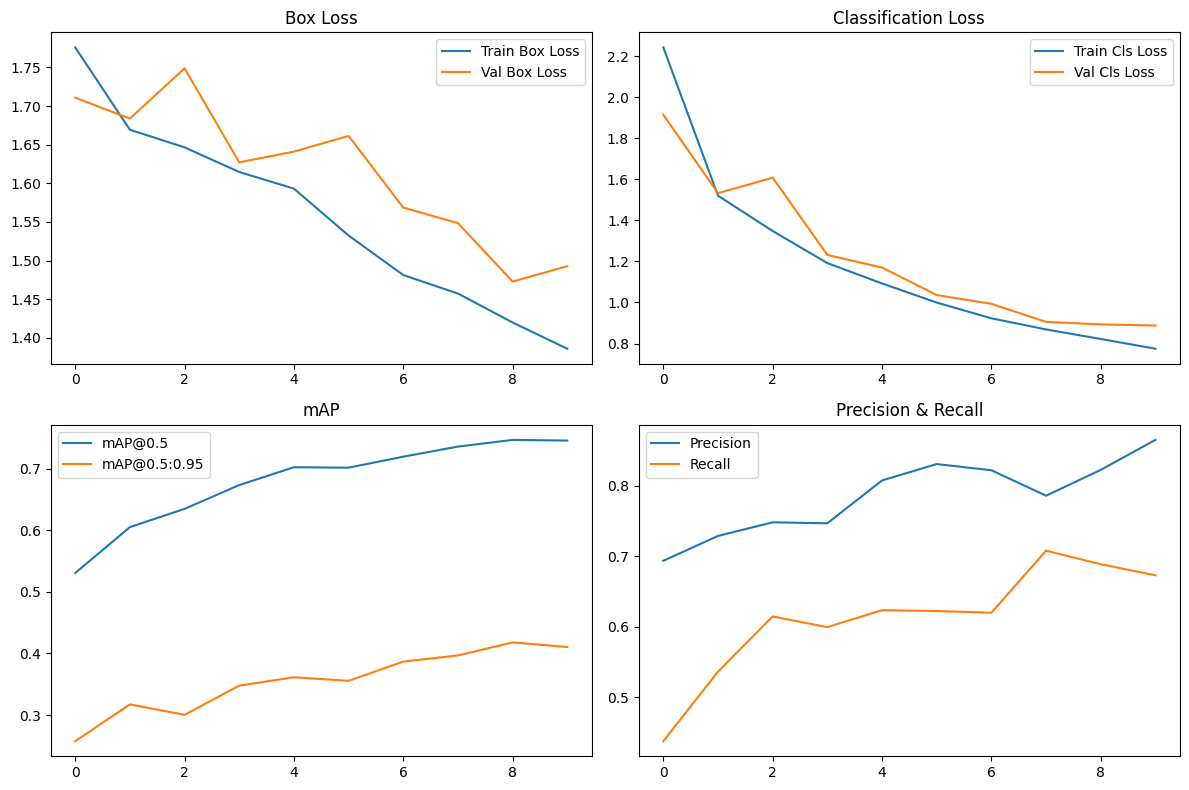

In [27]:
# ── 학습 결과 지표 확인 ──────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# runs/detect/aquarium_yolo11n/results.csv 에 학습 지표 저장됨
results_df = pd.read_csv('/content/runs/detect/hamelt_yolo11n-5/results.csv')
results_df.columns = results_df.columns.str.strip()

# 현재 DataFrame의 모든 열 이름을 출력하여 확인
print("DataFrame Columns:", results_df.columns.tolist())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(results_df['train/box_loss'], label='Train Box Loss')
axes[0,0].plot(results_df['val/box_loss'],   label='Val Box Loss')
axes[0,0].set_title('Box Loss'); axes[0,0].legend()

axes[0,1].plot(results_df['train/cls_loss'], label='Train Cls Loss')
axes[0,1].plot(results_df['val/cls_loss'],   label='Val Cls Loss')
axes[0,1].set_title('Classification Loss'); axes[0,1].legend()

# mAP, Precision, Recall 관련 열 이름을 수정하여 플롯
axes[1,0].plot(results_df['metrics/mAP50(B)'],    label='mAP@0.5')
axes[1,0].plot(results_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
axes[1,0].set_title('mAP'); axes[1,0].legend()

axes[1,1].plot(results_df['metrics/precision(B)'], label='Precision')
axes[1,1].plot(results_df['metrics/recall(B)'],    label='Recall')
axes[1,1].set_title('Precision & Recall'); axes[1,1].legend()

plt.tight_layout()
plt.show()

In [28]:
# 모델 성능 평가
best = '/content/runs/detect/hamelt_yolo11n-5/weights/best.pt'     # ... code here
m = YOLO(best)
metrics = m.val()

print(f'mAP@0.5      : {metrics.box.map50:.3f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.3f}')
for i, name in m.names.items():
    print(f'  {name:12s} P {metrics.box.p[i]:.3f}  R {metrics.box.r[i]:.3f}')

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1779.3±398.3 MB/s, size: 84.3 KB)
val: Scanning /content/helmet--1/valid/labels.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113 26.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.8it/s 2.8s
                   all        113        523      0.821      0.689      0.746      0.418
             No-helmet         17         87      0.785      0.529      0.583      0.297
                helmet        110        436      0.858      0.849      0.909      0.538
Speed: 4.7ms preprocess, 5.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5      : 0.746
mAP@0.5:0.95 : 0.418
  No-helmet    P 0.785  R 0.529
  helmet       P 0.858  R

### 워크시트 기록
| 항목 | 값 |
|---|---|
| mAP@0.5 | |
| `no_helmet` 클래스의 Recall | |
| 가장 자주 틀리는 상황 3가지 | |

> **안전 관점** : `no_helmet` 의 **Recall**을 특히 눈여겨본다. 놓치는 것이 가장 위험하다.

## **4. 객체 검출 (Inference / Predict)**

In [30]:
# [연습] test 폴더 이미지를 대상으로 predict 수행 (결과 저장 옵션 포함)
# 힌트:
#   results = model.predict(
#       source='./dataset/test/images',
#       save=True,
#       conf=0.25,
#   )

# ── 학습된 모델(best.pt)로 새 이미지 탐지 ──────────────────────

# 학습된 best.pt 경로 지정 ───────────────────────
best_model_path = '/content/runs/detect/hamelt_yolo11n-5/weights/best.pt'         # ... code here

# best.pt를 추론용 모델로 로드 ───────────────────
best_model =YOLO(best_model_path)          # ... code here

# 테스트 이미지 추론 ─────────────────────────────
test_results =best_model.predict(
    source='/content/helmet--1/test/images',
    save=True,
    conf=0.3

)           # ... code here

print(f"탐지 완료 — {len(test_results)}장")


image 1/112 /content/helmet--1/test/images/hard_hat_workers1003_png_jpg.rf.82722597022dfe6d65e9b6d86cd2e08c.jpg: 640x640 1 No-helmet, 4 helmets, 7.9ms
image 2/112 /content/helmet--1/test/images/hard_hat_workers1035_png_jpg.rf.549873c210750a089721035166a89e41.jpg: 640x640 11 No-helmets, 8.6ms
image 3/112 /content/helmet--1/test/images/hard_hat_workers103_png_jpg.rf.155de2e612c5247a401d5744d85c3ebb.jpg: 640x640 2 helmets, 7.9ms
image 4/112 /content/helmet--1/test/images/hard_hat_workers1040_png_jpg.rf.d0bc55006105abe2496847e22a9b8dd9.jpg: 640x640 4 helmets, 7.8ms
image 5/112 /content/helmet--1/test/images/hard_hat_workers1042_png_jpg.rf.0eda1eda1542065d6501bb4f1d6750de.jpg: 640x640 2 helmets, 9.5ms
image 6/112 /content/helmet--1/test/images/hard_hat_workers1059_png_jpg.rf.2eb91de83df0e510b1a3d9158e0faa37.jpg: 640x640 5 No-helmets, 8.1ms
image 7/112 /content/helmet--1/test/images/hard_hat_workers1099_png_jpg.rf.439e91a2dc7539bb766b75d54ece50ae.jpg: 640x640 4 No-helmets, 1 helmet, 9.7ms
i

## 5.실제 이미지로 확인

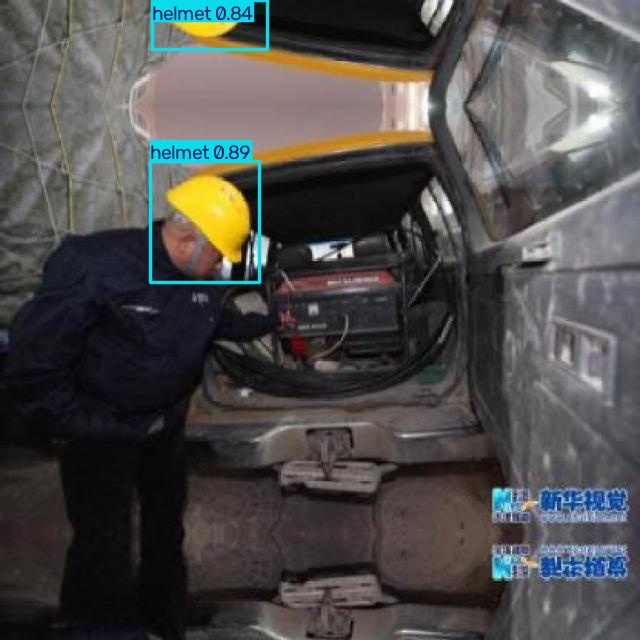

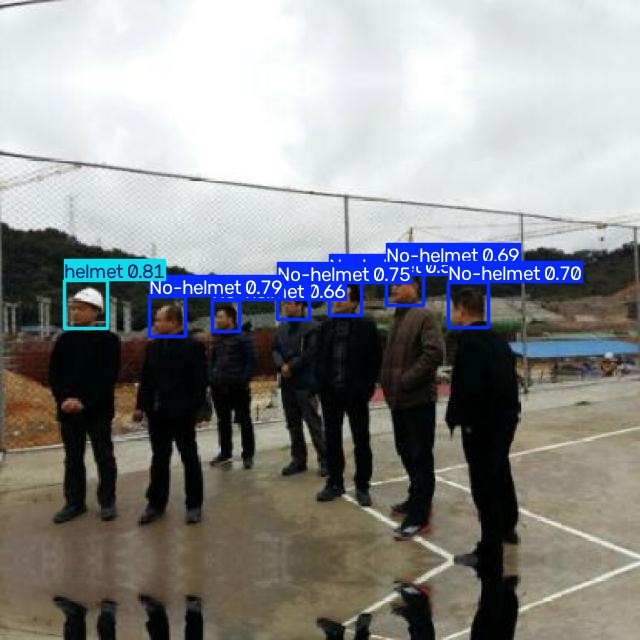

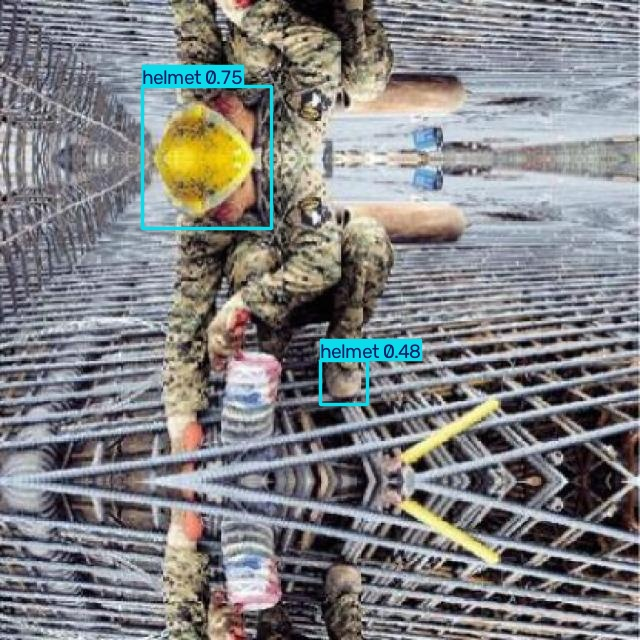

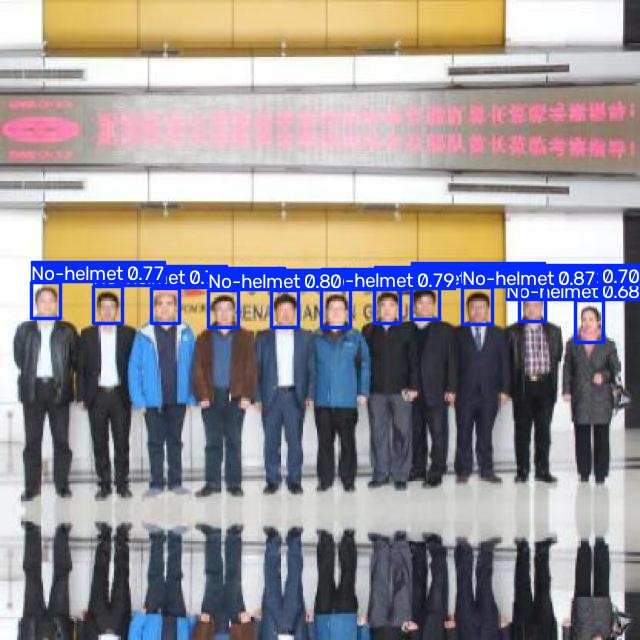

In [31]:
# ── 탐지 결과 이미지 표시 ────────────────────────────────────────
from PIL import Image
from IPython.display import display
import glob

result_images = glob.glob('./runs/detect/predict/*.jpg')[:4]
for img_path in result_images:
    with Image.open(img_path) as img:
        display(img)

## [STEP 6] 산출물 정리 — 경량화 노트북으로 넘길 꾸러미 만들기

학습이 끝났다. 이제 **다음 노트북(`02b` 경량화)이 그대로 받아 쓸 수 있는 형태**로 묶는다.

### 왜 이 단계가 따로 필요한가

`runs/detect/safety_yolov11n/` 폴더를 통째로 압축하면 안 된다.
그 안에는 학습 로그·그래프·중간 가중치가 뒤섞여 있고, 정작 **경량화에 필요한 것이 빠진다.**

| 경량화 노트북이 필요로 하는 것 | 어디서 오나 |
| --- | --- |
| `best.pt` | 학습 결과 가중치 |
| `safety_classes.json` | **클래스 번호↔이름 사전** — 아두이노 연동의 기준 |
| `data.yaml` | 정적 INT8 캘리브레이션 + 정확도 측정 |
| `safety_dataset/valid/` | **캘리브레이션용 실제 사진** — 이게 없으면 INT8 변환이 실패한다 |

네 가지를 한 폴더에 모아 `safety_train_out.zip` 하나로 만든다.

In [32]:
import os, json, yaml, shutil
from pathlib import Path
from ultralytics import YOLO

# ── 경로 정리 (학습 셀에서 쓴 이름과 맞춘다) ──────────────────────
RUN_DIR  = Path('/content/runs/detect/hamelt_yolo11n-5')  # ... code here
BEST_PT  = RUN_DIR / 'weights' / 'best.pt'
DATA_DIR = Path('/content/helmet--1')          # Roboflow 다운로드 폴더
SRC_YAML = DATA_DIR / 'data.yaml'

assert BEST_PT.exists(),  f'best.pt 를 찾지 못했다 : {BEST_PT}'
assert DATA_DIR.exists(), f'데이터셋 폴더를 찾지 못했다 : {DATA_DIR}'

# 클래스 이름은 모델에서 직접 읽는다 (yaml 과 어긋날 일이 없다)
names = [YOLO(str(BEST_PT)).names[i] for i in sorted(YOLO(str(BEST_PT)).names)]
print('가중치 :', BEST_PT)
print('클래스 :', {i: n for i, n in enumerate(names)})

가중치 : /content/runs/detect/hamelt_yolo11n-5/weights/best.pt
클래스 : {0: 'No-helmet', 1: 'helmet'}


In [33]:
OUT = Path('/content/safety_train_out')
shutil.rmtree(OUT, ignore_errors=True)
OUT.mkdir(parents=True)

# 1) 가중치 ─────────────────────────────────────────────────────
shutil.copy(BEST_PT, OUT / 'best.pt')

# 2) 클래스 사전 ────────────────────────────────────────────────
(OUT / 'safety_classes.json').write_text(
    json.dumps(names, ensure_ascii=False, indent=2), encoding='utf-8')

# 3) 캘리브레이션·검증용 사진 ───────────────────────────────────
#    valid 는 통째로, test 는 있으면 함께 넣는다.
for split in ('valid', 'test'):
    src = DATA_DIR / split
    if src.exists():
        shutil.copytree(src, OUT / 'safety_dataset' / split, dirs_exist_ok=True)
        n = len(list((OUT / 'safety_dataset' / split / 'images').glob('*')))
        print(f'  {split:6s} {n:4d} 장 복사')

# 4) data.yaml — 경로를 '이식 가능하게' 다시 쓴다 ★ ─────────────
#    원본의 path 는 /content/helmet--1 이라는 절대 경로다.
#    압축을 다른 곳에 풀면 그 경로가 없어 INT8 변환이 실패한다.
cfg = {
    'path':  'safety_dataset',      # zip 안에서의 상대 위치
    'train': 'valid/images',        # 재학습은 하지 않으므로 valid 를 함께 쓴다
    'val':   'valid/images',
    'names': names,
    'nc':    len(names),
}
with open(OUT / 'data.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(cfg, f, sort_keys=False, allow_unicode=True)

print('\ndata.yaml :')
print(yaml.dump(cfg, allow_unicode=True))

  valid   113 장 복사
  test    112 장 복사

data.yaml :
names:
- No-helmet
- helmet
nc: 2
path: safety_dataset
train: valid/images
val: valid/images



In [34]:
# 5) (선택) 학습 리포트 — 가중치 말고 그래프만 골라 담는다
report = OUT / 'train_report'
report.mkdir(exist_ok=True)
for f in ['results.csv', 'results.png', 'confusion_matrix.png',
          'BoxPR_curve.png', 'labels.jpg']:
    if (RUN_DIR / f).exists():
        shutil.copy(RUN_DIR / f, report / f)
print('리포트 :', sorted(p.name for p in report.glob('*')))

리포트 : ['BoxPR_curve.png', 'confusion_matrix.png', 'labels.jpg', 'results.csv', 'results.png']


### 검증 — 다음 노트북이 실제로 열 수 있는지 지금 확인한다


In [35]:
ok = True
need = {
    'best.pt':                    '가중치',
    'safety_classes.json':        '클래스 사전',
    'data.yaml':                  '데이터 설정',
    'safety_dataset/valid/images': '캘리브레이션 사진',
}
for rel, desc in need.items():
    p = OUT / rel
    exists = p.exists()
    ok &= exists
    print(f'  [{"O" if exists else "X"}] {rel:30s} {desc}')

n_img = len(list((OUT / 'safety_dataset/valid/images').glob('*'))) if ok else 0
if n_img < 50:
    print(f'\n  경고 : 캘리브레이션 사진이 {n_img}장뿐이다. 정적 INT8 정확도가 불안정할 수 있다.')

total = sum(p.stat().st_size for p in OUT.rglob('*') if p.is_file()) / 1024 / 1024
print(f'\n총 용량 : {total:.1f} MB')
assert ok, '빠진 파일이 있다 — 위 X 항목을 확인한다'
print('검증 통과')

  [O] best.pt                        가중치
  [O] safety_classes.json            클래스 사전
  [O] data.yaml                      데이터 설정
  [O] safety_dataset/valid/images    캘리브레이션 사진

총 용량 : 18.6 MB
검증 통과


In [36]:
# 6) 압축 — root_dir 를 지정해야 zip 안에 쓸데없는 상위 경로가 안 들어간다
zip_path = shutil.make_archive('/content/safety_train_out', 'zip', root_dir=OUT)
print(f'{zip_path}  ({os.path.getsize(zip_path)/1024/1024:.1f} MB)\n')

# zip 안을 눈으로 확인한다
import zipfile
with zipfile.ZipFile(zip_path) as z:
    entries = z.namelist()
print('zip 최상위 :', sorted({e.split("/")[0] for e in entries}))
print('총 항목    :', len(entries))

/content/safety_train_out.zip  (18.0 MB)

zip 최상위 : ['best.pt', 'data.yaml', 'safety_classes.json', 'safety_dataset', 'train_report']
총 항목    : 467


In [37]:
from google.colab import files
files.download('/content/safety_train_out.zip')
print('Colab 세션은 언제든 끊긴다 — 지금 받아서 클라우드와 USB 두 곳에 백업한다.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Colab 세션은 언제든 끊긴다 — 지금 받아서 클라우드와 USB 두 곳에 백업한다.


### 흔한 실수 세 가지

| 하지 말 것 | 왜 |
| --- | --- |
| `!zip -r out.zip /content/runs/detect/...` | **절대 경로가 통째로 들어간다.** 풀면 `content/runs/detect/...` 4단계 폴더가 생기고, 다음 노트북이 `best.pt` 를 못 찾는다 |
| `best.pt` 와 `data.yaml` 을 **따로따로** 내려받기 | 팀원마다 다른 폴더에 두게 되고, `data.yaml` 이 가리키는 사진이 어디 있는지 아무도 모른다 |
| 데이터셋 없이 `data.yaml` 만 넣기 | 정적 INT8은 **실제 사진으로 값의 범위를 잰다.** 사진이 없으면 변환 자체가 실패한다 |

> 압축 파일 하나에 **모델·사전·설정·사진**이 모두 들어 있어야 한다.
> "받는 사람이 이것만 있으면 되는가?" — 이 질문이 배포의 전부다.

---
## [STEP 7] PC에서 확인하기

`safety_train_out.zip` 을 PC에 풀면 `best.pt` 가 나온다. 그 폴더에서 아래 코드를 실행한다.

### 7-1. 이미지 한 장 추론

In [ ]:
from ultralytics import YOLO
import cv2, matplotlib.pyplot as plt

model = YOLO("best.pt")                      # 압축을 푼 폴더에서 실행한다
results = model("test_image.jpg", conf=0.3)  # 확인할 사진 이름으로 바꾼다

boxes = results[0].boxes
print("클래스 번호 :", boxes.cls.tolist())
print("신뢰도      :", [round(float(c), 2) for c in boxes.conf])
print("이름        :", [model.names[int(c)] for c in boxes.cls])

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

### 7-2. 웹캠 실시간 추론

**여기서 나오는 FPS를 적어 둔다.** D9에서 라즈베리파이의 FPS와 비교할 기준이 된다.
노트북 PC와 라즈베리파이의 차이를 숫자로 보는 순간, 경량화가 왜 필요한지 알게 된다.

In [ ]:
from ultralytics import YOLO
import cv2, time

model = YOLO("best.pt")
cap = cv2.VideoCapture(0)

tick, n, fps = time.time(), 0, 0.0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.3, verbose=False)
    img = results[0].plot()

    n += 1
    t = time.time()
    if t - tick >= 1.0:
        fps, n, tick = n / (t - tick), 0, t
    cv2.putText(img, f"{fps:.1f} FPS", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 180, 0), 2)

    cv2.imshow("YOLO Real-Time Detection", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

---
## 체크포인트

- [ ] `best.pt` 의 mAP@0.5 를 워크시트에 적었는가
- [ ] `No-helmet` 의 **Recall** 을 적었는가 (놓치는 것이 가장 위험하다)
- [ ] 클래스 **0번이 무엇인지** 팀원 전원이 답할 수 있는가
- [ ] `safety_train_out.zip` 검증 셀이 통과했는가
- [ ] zip 을 두 곳(클라우드·USB)에 백업했는가
- [ ] PC 웹캠 FPS 를 적어 두었는가

---
다음 : **`02b_convert_and_package_pc.ipynb`** 에서 이 `safety_train_out.zip` 을 받아
`best.pt` 를 라즈베리파이용 `.tflite` 로 경량화한다.
